In [39]:
# torch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.transforms import transforms
import torch.optim as optim
# utils
import os
from pathlib import Path
from glob import glob
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
# visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix

In [ ]:
# global variables
import os
from pathlib import Path
from glob import glob

device = "cuda" if torch.cuda.is_available() else "cpu"

# nombre de la carpeta donde está el dataset (relativa a la CWD del notebook)
dataset_name = "BrainMRI-Tumor-Classifier-BUENO"

def find_dataset_dir(name=dataset_name, start=None):
    start = Path(start or Path.cwd()).resolve()
    for p in [start] + list(start.parents):
        candidate = p / name
        if candidate.exists() and candidate.is_dir():
            return candidate
    return None

# localizar dataset (no cambiamos el CWD)
dataset_dir = find_dataset_dir()
if dataset_dir is None:
    # como fallback, aceptar ruta literal (por si ya es absoluta)
    candidate = Path(dataset_name)
    if candidate.exists() and candidate.is_dir():
        dataset_dir = candidate.resolve()

if dataset_dir is None:
    raise FileNotFoundError("No se encontró la carpeta 'BrainMRI-Tumor-Classifier-BUENO' desde CWD ni en los padres. CWD actual: " + str(Path.cwd()))

print("Dataset dir:", dataset_dir)

# rutas a subcarpetas
train_dir = str(dataset_dir / "Training")
test_dir = str(dataset_dir / "Testing")

image_size = (512, 512)
num_classes = 5

# función auxiliar para recoger imágenes (admite jpg, jpeg, png)
def gather_images(base_dir):
    patterns = ["*.jpg", "*.jpeg", "*.png"]
    paths = []
    for p in patterns:
        # se espera estructura base_dir/<class>/*.<ext>
        paths.extend(glob(os.path.join(base_dir, "*", p)))
    return sorted(paths)

train_paths = gather_images(train_dir)
test_paths = gather_images(test_dir)

# resumen rápido para depuración
print("Train samples:", len(train_paths))
print("Test samples:", len(test_paths))


Dataset dir: /mnt/c/Users/fabia/Desktop/Scripts/python/PDI/BrainMRI-Tumor-Classifier-BUENO
Dataset dir: /mnt/c/Users/fabia/Desktop/Scripts/python/PDI/BrainMRI-Tumor-Classifier-BUENO
Train samples: 5712
Test samples: 1311


In [11]:
# check device
device

'cuda'

In [41]:
# data augmentation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [42]:
# custom dataset class
class dataset(Dataset):
    def __init__(self,paths,transform=None):
        self.paths = paths
        self.transform = transform
        self.labels = [self.get_label(path) for path in self.paths]
        self.labels_to_index = {label:index for index,label in enumerate(list(set(self.labels)))}
    
    def __getitem__(self,index):
        img_path = self.paths[index]
        img = Image.open(img_path).convert('RGB') 
        label = self.labels[index]
        label_index = self.labels_to_index[label]
        
        if self.transform:
            img = self.transform(img)
        
        return img, label_index,label
    
    
    def __len__(self):
        return len(self.paths)
    
    
    def get_label(self, path):
        return os.path.basename(os.path.dirname(path))

In [43]:
train_dataset = dataset(train_paths, transform=train_transform)
test_dataset = dataset(test_paths, transform=test_transform)

In [ ]:
# --- División segura de test_dataset en val/test usando PyTorch ---
import torch

n = len(test_dataset)
print("len(test_dataset):", n)
if n == 0:
    raise ValueError("test_dataset tiene 0 muestras. Revisa 'test_paths' y las rutas (glob).")
if n < 2:
    raise ValueError(f"Imposible dividir: solo hay {n} muestra(s) en test_dataset.")

# dividir aproximadamente a la mitad (reproducible con semilla)
n_val = n // 2
n_test = n - n_val

generator = torch.Generator().manual_seed(ord("H"))
val_dataset, test_dataset = torch.utils.data.random_split(test_dataset, [n_val, n_test], generator=generator)

print(f"Split realizado: val={len(val_dataset)}, test={len(test_dataset)}")


Ejemplo test_paths (hasta 10): ['/mnt/c/Users/fabia/Desktop/Scripts/python/PDI/BrainMRI-Tumor-Classifier-BUENO/Testing/glioma/Te-glTr_0000.jpg', '/mnt/c/Users/fabia/Desktop/Scripts/python/PDI/BrainMRI-Tumor-Classifier-BUENO/Testing/glioma/Te-glTr_0001.jpg', '/mnt/c/Users/fabia/Desktop/Scripts/python/PDI/BrainMRI-Tumor-Classifier-BUENO/Testing/glioma/Te-glTr_0002.jpg', '/mnt/c/Users/fabia/Desktop/Scripts/python/PDI/BrainMRI-Tumor-Classifier-BUENO/Testing/glioma/Te-glTr_0003.jpg', '/mnt/c/Users/fabia/Desktop/Scripts/python/PDI/BrainMRI-Tumor-Classifier-BUENO/Testing/glioma/Te-glTr_0004.jpg', '/mnt/c/Users/fabia/Desktop/Scripts/python/PDI/BrainMRI-Tumor-Classifier-BUENO/Testing/glioma/Te-glTr_0005.jpg', '/mnt/c/Users/fabia/Desktop/Scripts/python/PDI/BrainMRI-Tumor-Classifier-BUENO/Testing/glioma/Te-glTr_0006.jpg', '/mnt/c/Users/fabia/Desktop/Scripts/python/PDI/BrainMRI-Tumor-Classifier-BUENO/Testing/glioma/Te-glTr_0007.jpg', '/mnt/c/Users/fabia/Desktop/Scripts/python/PDI/BrainMRI-Tumor-Cl

In [ ]:
# Nota: la división del `test_dataset` ya se realiza en la celda anterior (uso de `torch.utils.data.random_split`).
# Esta celda queda como marcador para evitar ejecuciones duplicadas.


In [46]:
print("len(val_dataset):", len(val_dataset))
print("len(test_dataset):", len(test_dataset))

len(val_dataset): 328
len(test_dataset): 328


In [47]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

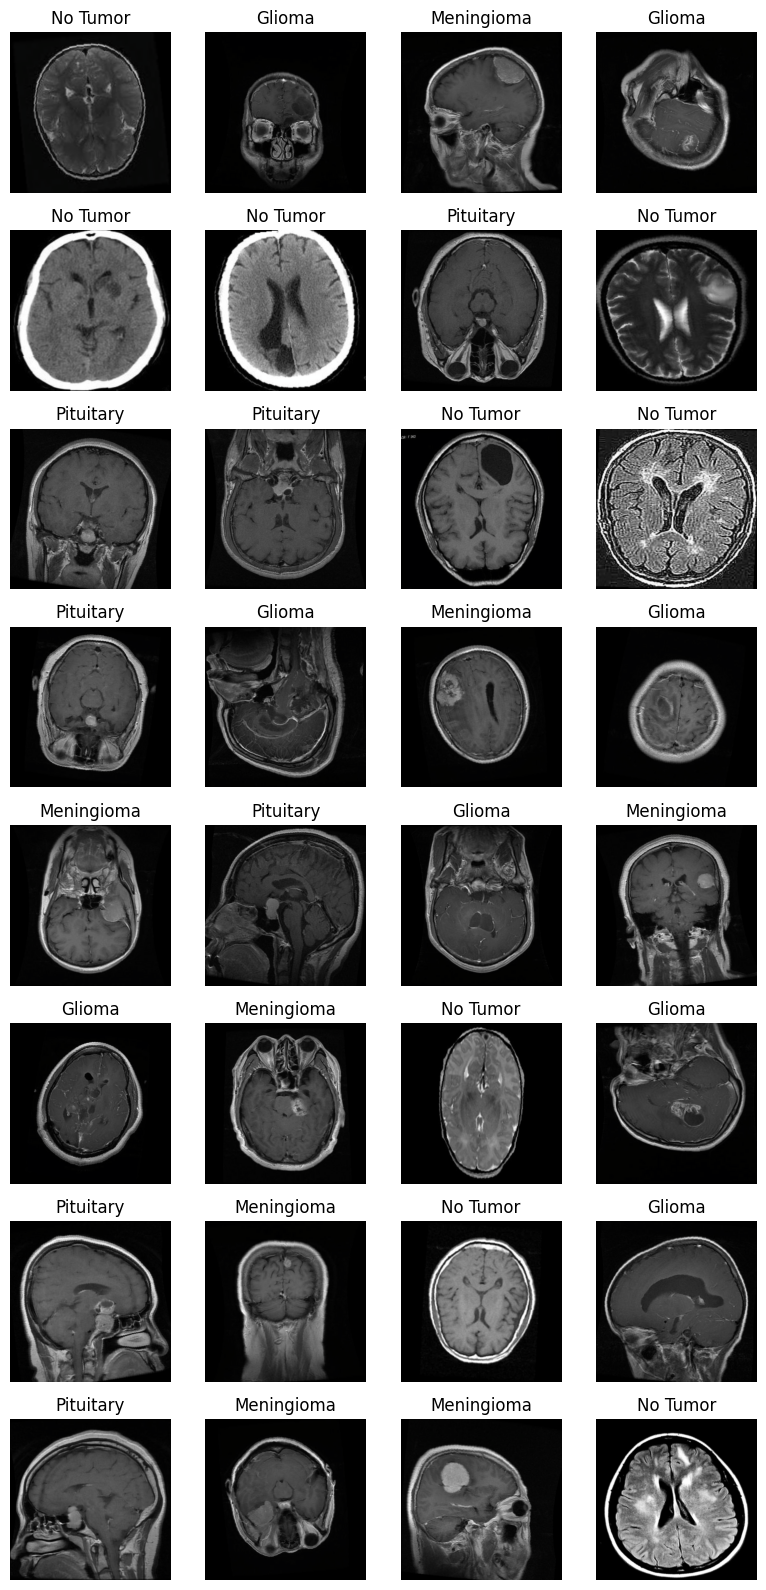

In [48]:
# display sample images with classes
train_iter = iter(train_loader)
images, labels_indices, labels = next(train_iter)

def imshow(input_images, labels_indices,labels):
    label_dict = {"notumor":"No Tumor", "glioma":"Glioma", "meningioma":"Meningioma","pituitary":"Pituitary"}
    input_images=input_images.numpy().transpose((0,2, 3, 1))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    input_images = std * input_images + mean
    input_images = np.clip(input_images, 0, 1)
    fig, axes = plt.subplots(8, 4, figsize=(8, 16))
    for i, ax in enumerate(axes.flat):
        ax.imshow(input_images[i])
        ax.axis('off')
        ax.set_title(label_dict[labels[i]], fontsize=12)
    plt.tight_layout()
    plt.show()


imshow(images, labels_indices,labels)

In [49]:
class MyModel(nn.Module):
    def __init__(self,num_classes):
        super(MyModel,self).__init__()
        
        self.conv1 = nn.Conv2d(3,32,kernel_size=4,stride=1,padding=0)
        self.bn1 = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(32,64,kernel_size=4,stride=1,padding=0)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(64,128,kernel_size=4,stride=1,padding=0)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.conv4 = nn.Conv2d(128,128,kernel_size=4,stride=1,padding=0)
        self.bn4 = nn.BatchNorm2d(128)
        
        self.pool = nn.MaxPool2d(kernel_size=3, stride=3)
        self.pool2= nn.MaxPool2d(kernel_size=3, stride=2)
        
        self.fc1 = nn.Linear(6*6*128,512)
        self.fc2 = nn.Linear(512,num_classes)
        
        self.flatten = nn.Flatten()
        self.relu = nn.ReLU() 
        self.dropout = nn.Dropout(0.5)
        
        
        
        
    def forward(self,x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool2(x)
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [50]:
model = MyModel(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.0002)

In [51]:
def train_epoch():
    model.train()
    total_loss = 0.0 
    total_correct = 0
    total_predictions = 0
    
    for batch_number, (images, labels_indices, labels) in enumerate(train_loader):
        images, labels_indices = images.to(device), labels_indices.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels_indices)
        total_loss += loss.item()
        
        # Calculate accuracy
        _, predicted = torch.max(outputs, 1)
        total_predictions += labels_indices.size(0)
        total_correct += (predicted == labels_indices).sum().item()
        
        loss.backward()
        optimizer.step()
        
        if (batch_number and batch_number % 150 == 0):
            c_loss = total_loss / (batch_number + 1)
            accuracy = total_correct / total_predictions
            print(f"Batch {batch_number}/{len(train_loader)}, Loss: {c_loss:0.4f}, Accuracy: {accuracy * 100:.2f}%")
    
    avg_loss = total_loss / len(train_loader)
    avg_accuracy = total_correct / total_predictions
    
    return avg_loss, avg_accuracy


In [52]:
def eval_model():
    model.eval()
    total_loss = 0.0 
    total_correct = 0
    total_predictions = 0
    
    with torch.no_grad():
        for batch_number, (images, labels_indices, labels) in enumerate(val_loader):
            images, labels_indices = images.to(device), labels_indices.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels_indices)
            total_loss += loss.item()
            
            # Calculate accuracy
            _, predicted = torch.max(outputs, 1)
            total_predictions += labels_indices.size(0)
            total_correct += (predicted == labels_indices).sum().item()
            
    avg_loss = total_loss / len(val_loader)
    avg_accuracy = total_correct / total_predictions
    
    return avg_loss, avg_accuracy


In [53]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

In [54]:
best_score = float("inf")
n_epochs = 40
tolerance = 0

for epoch in range(n_epochs):
    print(f"Epoch {epoch},   ", end="")
    avg_train_loss, train_accuracy = train_epoch()
    avg_eval_loss, eval_accuracy = eval_model()
    
    if avg_eval_loss < best_score:
        best_score = avg_eval_loss
        torch.save(model.state_dict(), f"model_{epoch+1}")
        tolerance = 0
    else:
        tolerance += 1
        if tolerance >= 8:
            break
            
    train_losses.append(avg_train_loss)
    val_losses.append(avg_eval_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(eval_accuracy)
    
    print(f"Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_accuracy * 100:.2f}%")
    print(f"Eval Loss: {avg_eval_loss:.4f}, Eval Accuracy: {eval_accuracy * 100:.2f}%")
    print("#" * 70)


Epoch 0,   

/home/fabia/miniforge3/envs/pdi/lib/python3.12/site-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x61952 and 4608x512)

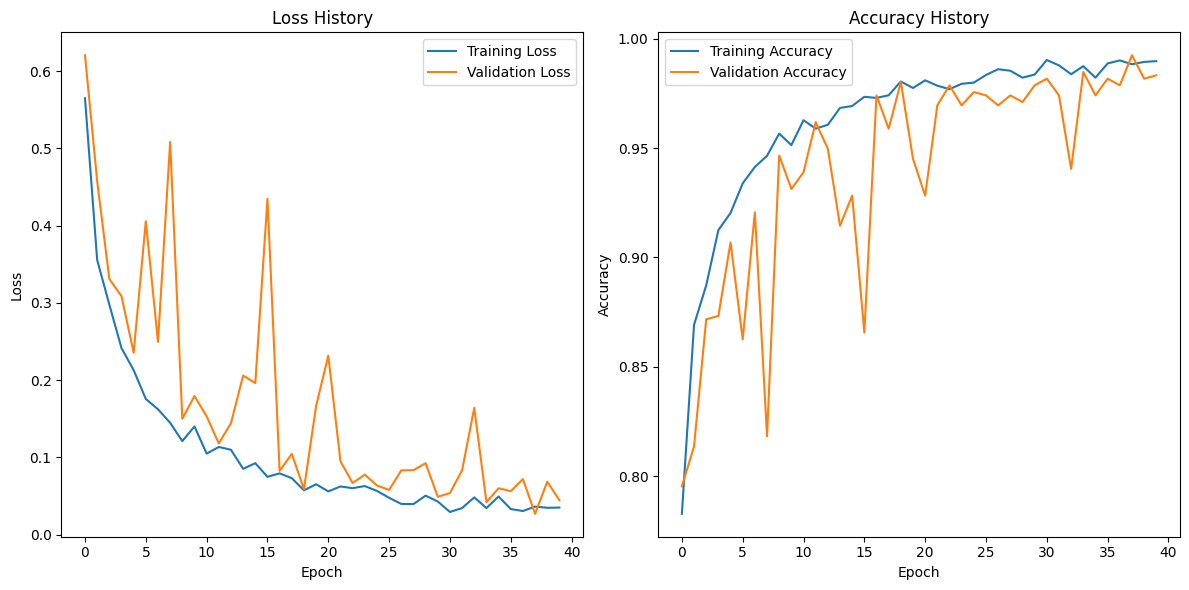

In [16]:
# Visualize training history
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss History')

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy History')

plt.tight_layout()
plt.show()

In [17]:
models = glob("/kaggle/working/*")
model_num = [int(i.split("_")[-1]) for i in models if i.split("_")[-1].isdigit()]
best_model_path = "/kaggle/working/model_" + str(sorted(model_num)[-1])
best_model_path

'/kaggle/working/model_38'

In [18]:
best_model = MyModel(num_classes).to(device)

best_model.load_state_dict(torch.load(best_model_path, map_location=device))

<All keys matched successfully>

In [19]:
def predict(
    model:nn.Module, 
    sample_loader:torch.utils.data.DataLoader,
    device:torch.device) -> np.ndarray:
    model.eval()
    predictions = []
    with torch.inference_mode():
        for batch, (X, y,labels) in enumerate(sample_loader):
            X, y = X.to(device), y.to(device)
            y_pred = model(X) 
            predictions.append(y_pred.cpu().numpy())
        
    return np.vstack(predictions)

In [20]:
best_model_props = predict(best_model, test_loader, device)
best_model_preds = np.argmax(best_model_props, axis=1)
best_model_preds.shape[0]

656

In [21]:
gen_labels_test_set = [label[1] for label in test_dataset]
len(gen_labels_test_set)

656

In [22]:
print(f"Best Model Test Accuracy: {round(accuracy_score(gen_labels_test_set,best_model_preds)*100,2)}%")

Best Model Test Accuracy: 99.39%


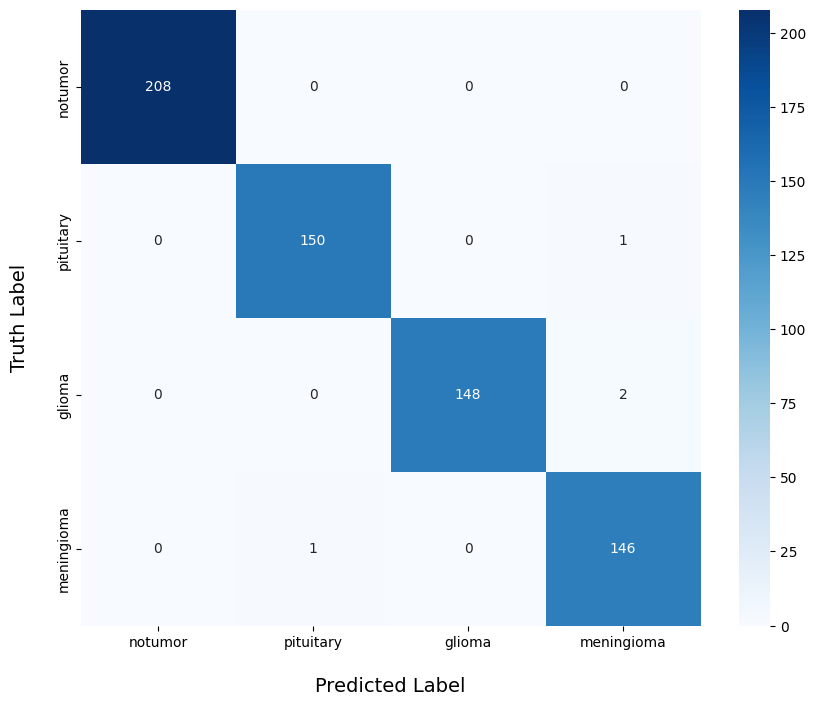

In [23]:
cm = confusion_matrix(gen_labels_test_set, best_model_preds)
labels = set([label[2] for label in test_dataset])
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label', labelpad=20, fontsize=14)
plt.ylabel('Truth Label', labelpad=20, fontsize=14)
plt.show()